# Statistical Analysis

Para este notebook se neceista el siguiente dataset: panel_BALANCED_MAIN_MarJul_2020_2024_2025_AB_v1.csv

In [ ]:
# Statistical Analysis Functions for All Contaminants
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.join("..","data","processed")
IN_FILE  = os.path.join(DATA_DIR, "panel_BALANCED_MAIN_MarJul_2020_2024_2025_AB_v1.csv")

main = pd.read_csv(IN_FILE, parse_dates=["date"], engine="pyarrow")

def daily_max8h_for_group(g, contaminant):
    """Calculate daily maximum 8-hour average for a contaminant group"""
    # Reindex a grilla horaria para rolling robusto
    idx = pd.date_range(g["date"].min().floor("H"), g["date"].max().ceil("H"), freq="H")
    s = g.set_index("date")[contaminant].reindex(idx)
    # Promedio móvil de 8h (permitimos algunos NaN)
    m8 = s.rolling(window=8, min_periods=6).mean()
    # Máximo diario
    dmax = m8.resample("D").max()
    out = dmax.to_frame(f"{contaminant}_max8h").reset_index().rename(columns={"index":"day"})
    out["station_code"] = g["station_code"].iat[0]
    out["period_window"] = g["period_window"].iat[0]
    return out

def analyze_contaminant_boxplot(contaminant_name, save_csv=False):
    """Create boxplot analysis for a specific contaminant"""
    # Filter data for the contaminant
    contaminant_data = main.loc[main[contaminant_name].notna(), ["date","station_code","period_window",contaminant_name]].copy()
    
    if contaminant_data.empty:
        print(f"No data available for {contaminant_name}")
        return
    
    # 1) Máximo 8h diario por estación y ventana
    by_sta = (contaminant_data.sort_values("date")
                .groupby(["period_window","station_code"], group_keys=False)
                .apply(lambda g: daily_max8h_for_group(g, contaminant_name)))

    # 2) Serie "ciudad": promedio entre estaciones por día (igual peso)
    city_daily = (by_sta.groupby(["period_window","day"])[f"{contaminant_name}_max8h"]
                       .mean()
                       .reset_index())

    # 3) Guardar tabla (opcional)
    if save_csv:
        out_tbl = os.path.join(DATA_DIR, f"{contaminant_name}_max8h_daily_city_MAIN_MarJul_2020_2024_2025.csv")
        city_daily.to_csv(out_tbl, index=False)
        print(f"Guardado: {out_tbl}")

    # 4) Boxplot comparativo por ventana
    order = ["pandemic_MarJul2020","baseline_MarJul2024","current_MarJul2025"]
    data = [city_daily.loc[city_daily["period_window"]==w, f"{contaminant_name}_max8h"].dropna().values for w in order]

    plt.figure(figsize=(6,4))
    plt.boxplot(data, labels=["Mar–Jun 2020","Mar–Jul 2024","Mar–Jul 2025"], showfliers=False)
    plt.ylabel(f"{contaminant_name} (máximo 8 h diario)")
    plt.title(f"{contaminant_name} — comparativo por ventana (panel MAIN)")
    plt.tight_layout()
    plt.show()

# Analyze all contaminants (save CSV only for first contaminant as example)
contaminants = ["PM2.5", "NO2", "CO", "NO", "NOX_final"]

for i, contaminant in enumerate(contaminants):
    print(f"\n{'='*50}")
    print(f"Analyzing {contaminant}")
    print(f"{'='*50}")
    analyze_contaminant_boxplot(contaminant, save_csv=(i==0))


Time Series Overview: PM2.5


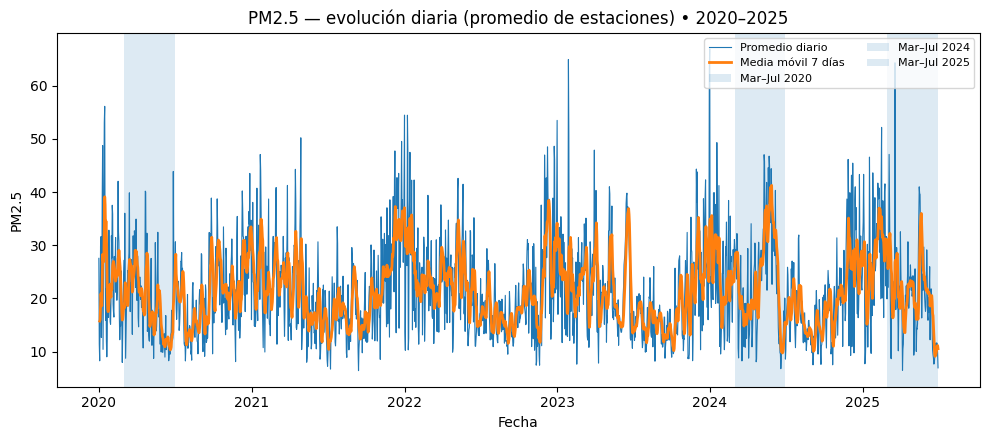


Time Series Overview: NO2


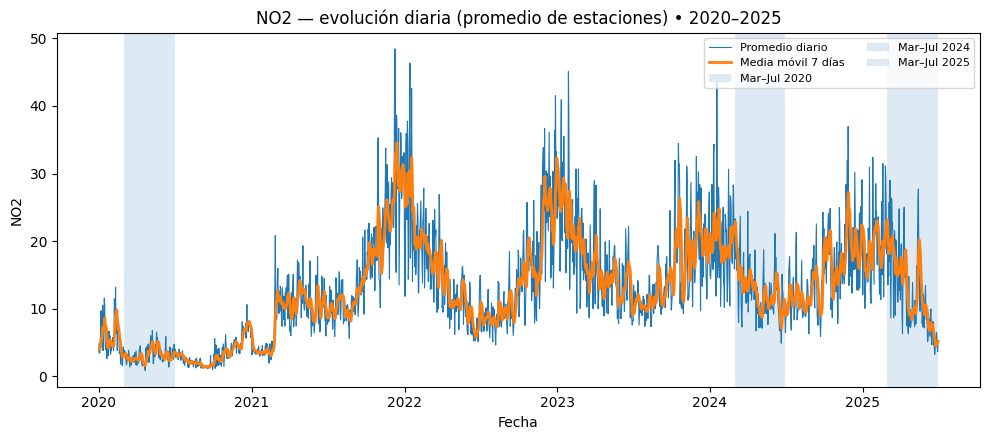


Time Series Overview: CO


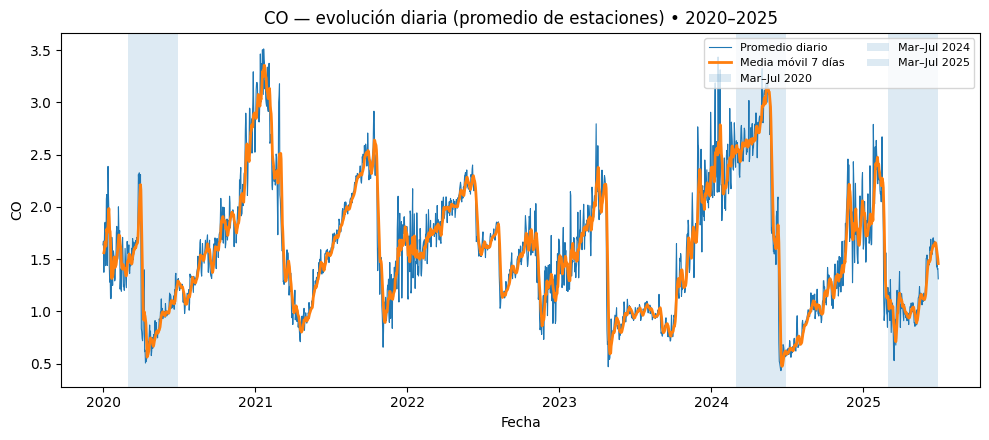


Time Series Overview: NO


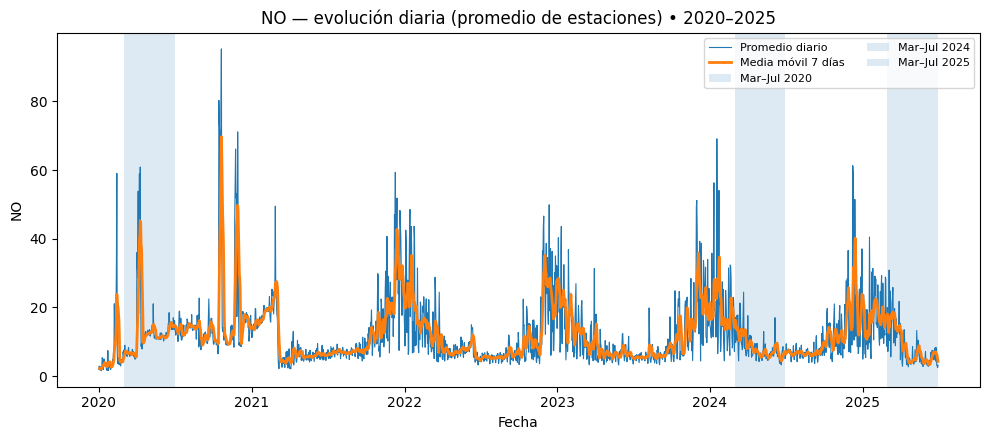


Time Series Overview: NOX_final


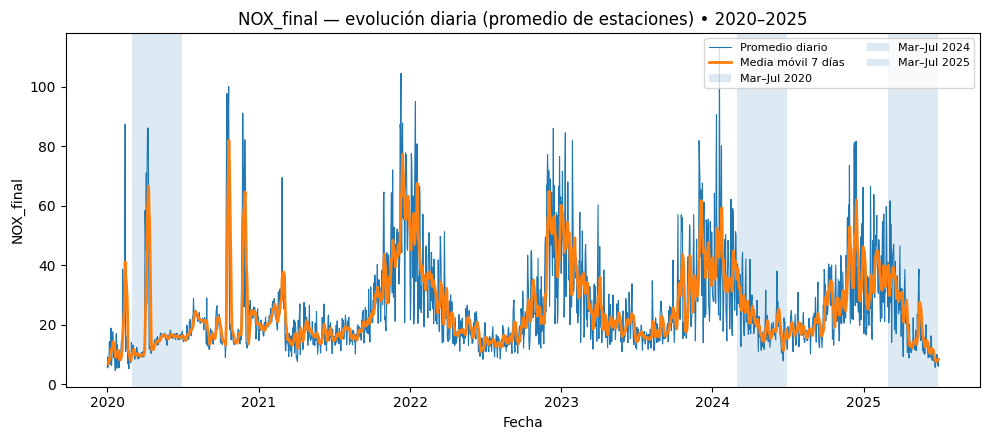

In [2]:
# Time Series Analysis Function for All Contaminants
import pandas as pd
import matplotlib.pyplot as plt

def analyze_contaminant_timeseries_overview(contaminant_name, df_path="../data/processed/pre_imputation_subset_AB_v1.csv"):
    """Create overview time series plot for a contaminant across all years"""
    
    # 1) Carga (ajusta la ruta a tu proyecto)
    df = pd.read_csv(df_path, parse_dates=["date"], engine="pyarrow")
    
    # Check if contaminant exists
    if contaminant_name not in df.columns:
        print(f"Contaminant {contaminant_name} not found in dataset")
        return
    
    # 2) Promedio diario del contaminante (promedia entre estaciones cada día)
    daily_data = (df.dropna(subset=[contaminant_name])
                    .assign(day=lambda x: x["date"].dt.floor("D"))
                    .groupby("day")[contaminant_name].mean()
                    .to_frame(f"{contaminant_name}_diario"))
    daily_data[f"{contaminant_name}_7d"] = daily_data[f"{contaminant_name}_diario"].rolling(7, min_periods=3).mean()

    # 3) Ventanas a resaltar (Mar–Jul 2020, 2024 y 2025)
    windows = [
        ("2020-03-01","2020-06-30","Mar–Jul 2020"),
        ("2024-03-01","2024-06-30","Mar–Jul 2024"),
        ("2025-03-01","2025-06-30","Mar–Jul 2025"),
    ]

    # 4) Gráfico (una sola figura, sin estilos especiales)
    plt.figure(figsize=(10,4.5))
    plt.plot(daily_data.index, daily_data[f"{contaminant_name}_diario"], linewidth=0.8, label="Promedio diario")
    plt.plot(daily_data.index, daily_data[f"{contaminant_name}_7d"], linewidth=2.0, label="Media móvil 7 días")

    for start, end, label in windows:
        plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, label=label)

    plt.title(f"{contaminant_name} — evolución diaria (promedio de estaciones) • 2020–2025")
    plt.xlabel("Fecha")
    plt.ylabel(contaminant_name)
    plt.legend(loc="upper right", ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

# Analyze all contaminants with overview time series
contaminants = ["PM2.5", "NO2", "CO", "NO", "NOX_final"]

for contaminant in contaminants:
    print(f"\n{'='*50}")
    print(f"Time Series Overview: {contaminant}")
    print(f"{'='*50}")
    analyze_contaminant_timeseries_overview(contaminant)


Detailed Time Series Analysis: PM2.5


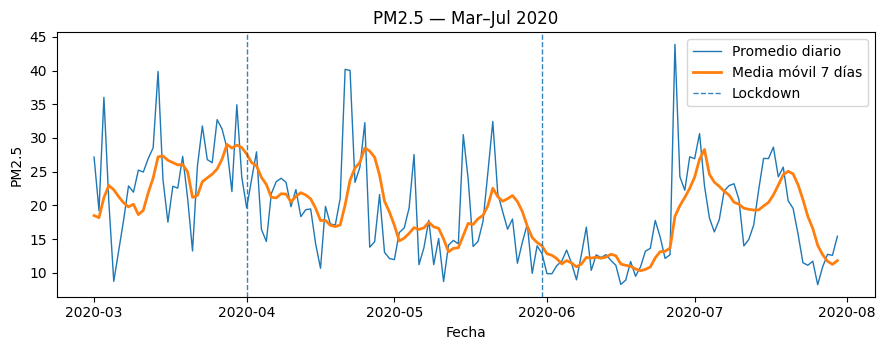

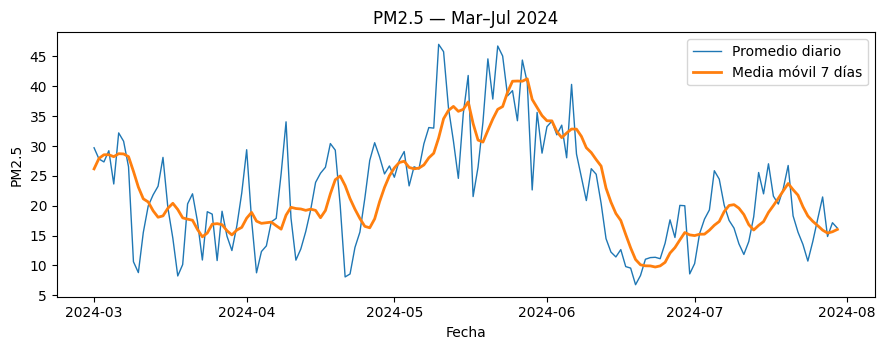

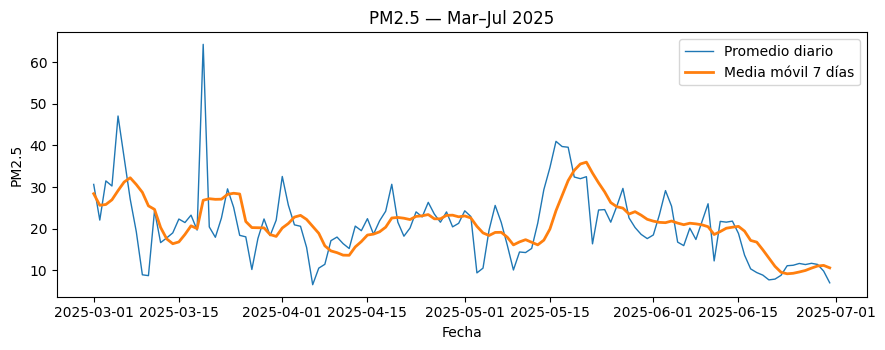


Detailed Time Series Analysis: NO2


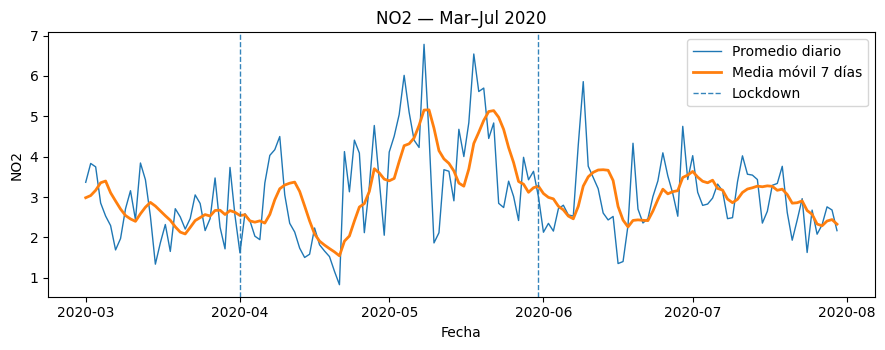

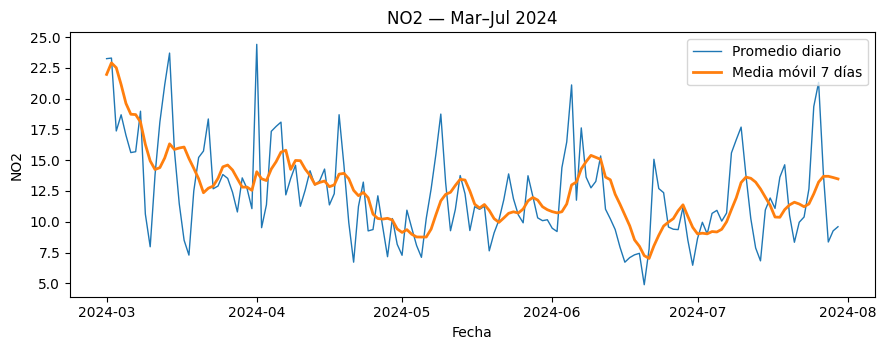

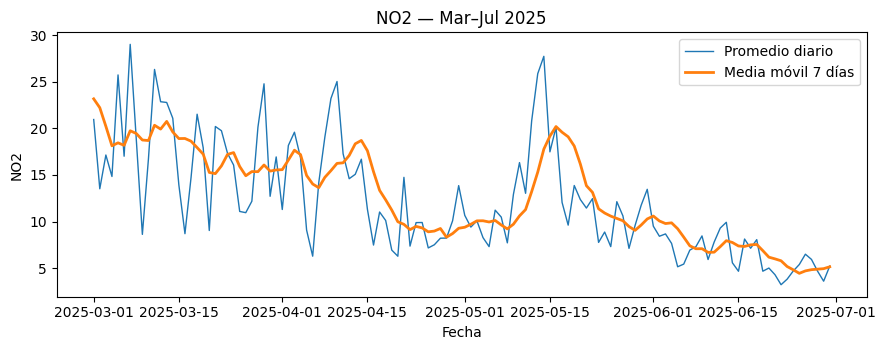


Detailed Time Series Analysis: CO


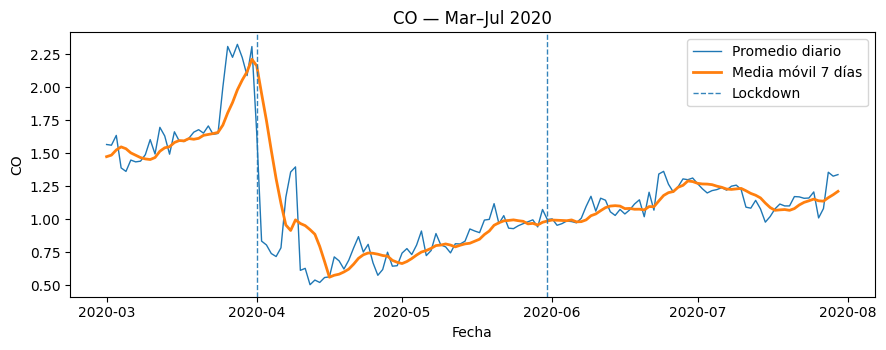

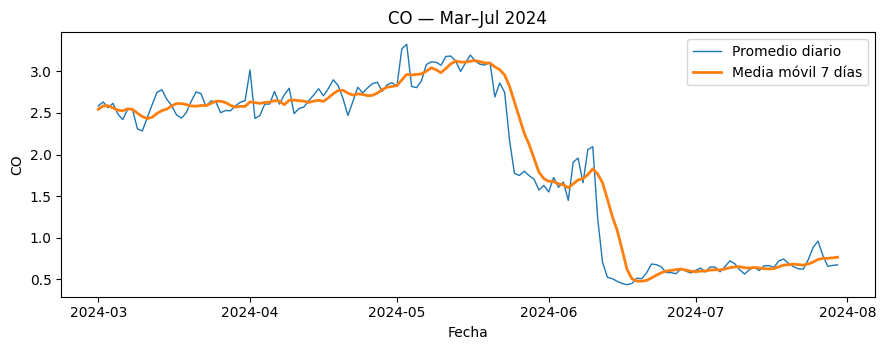

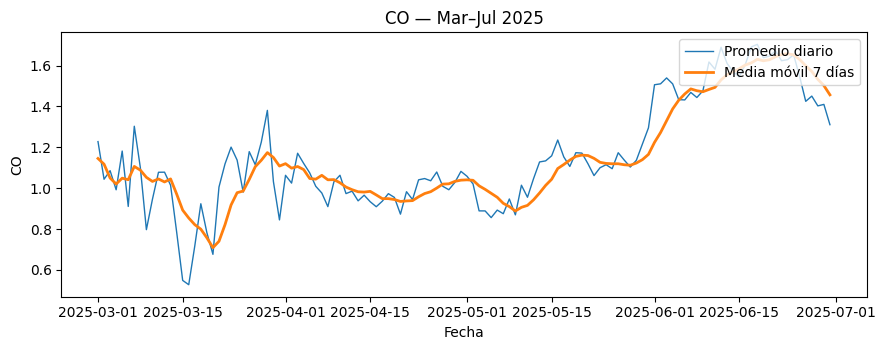


Detailed Time Series Analysis: NO


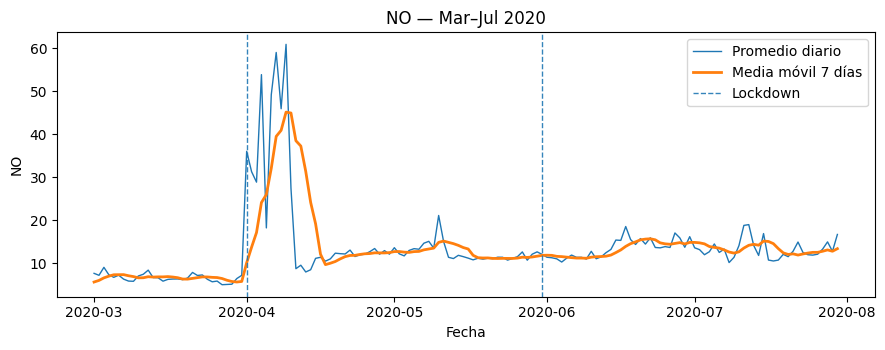

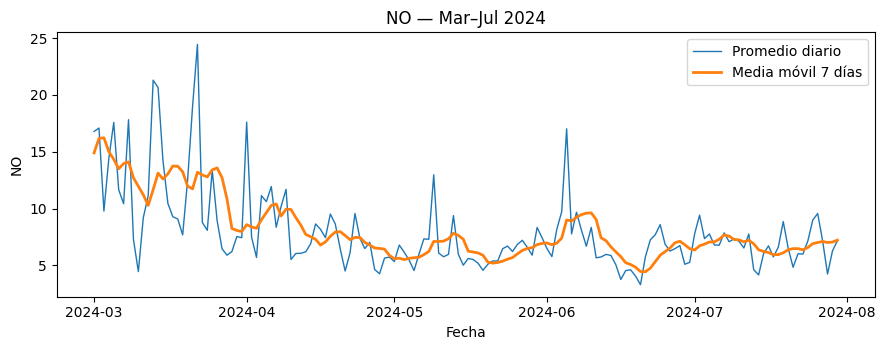

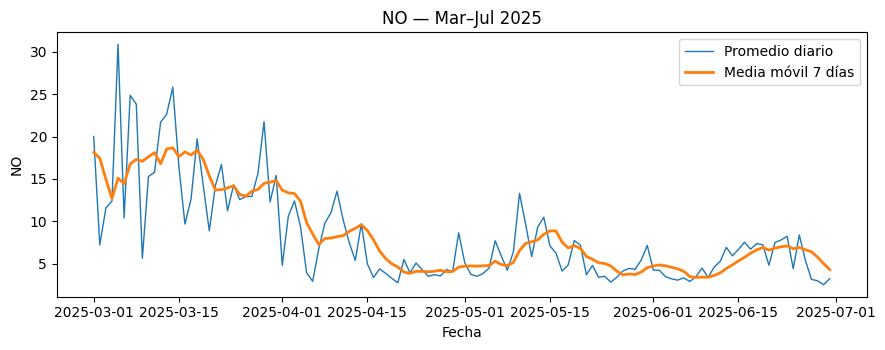


Detailed Time Series Analysis: NOX_final


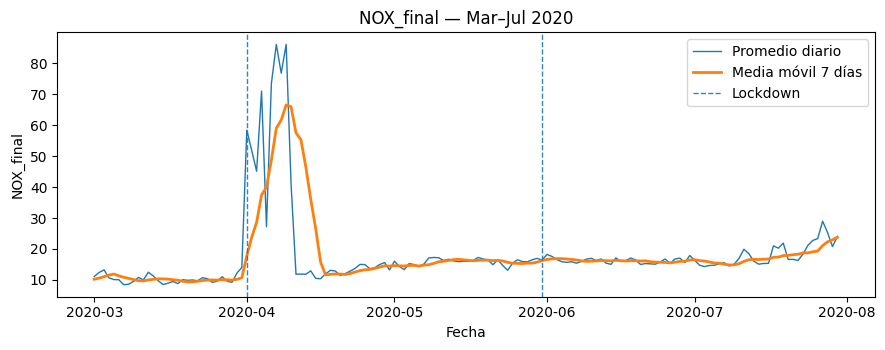

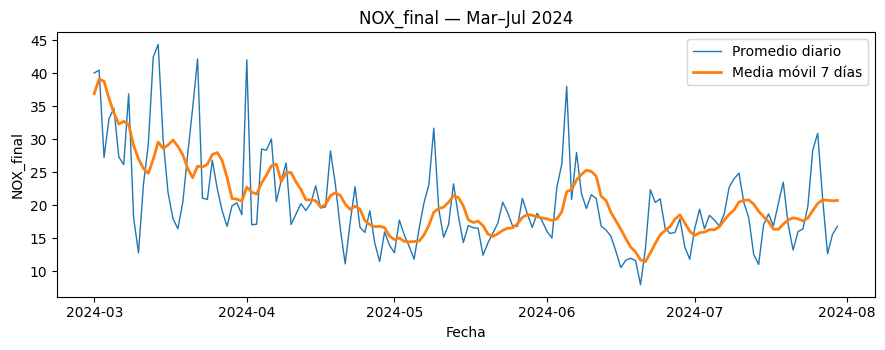

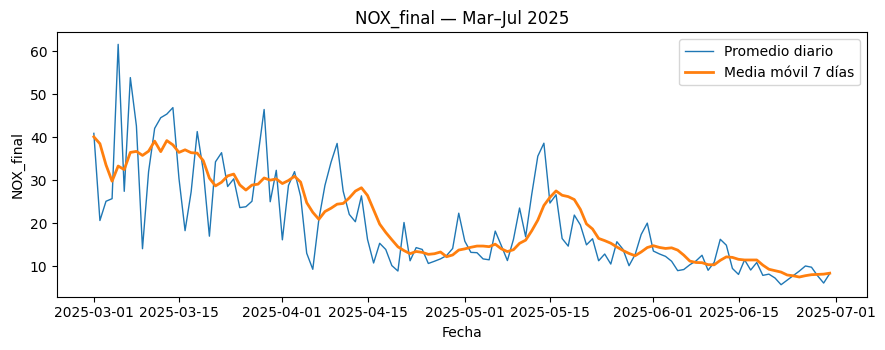

In [3]:
# Detailed Time Series Analysis by Periods for All Contaminants
def analyze_contaminant_timeseries_detailed(contaminant_name, df_path="../data/processed/pre_imputation_subset_AB_v1.csv"):
    """Create detailed time series plots for specific periods"""
    
    # Carga (ajusta si tu ruta difiere)
    df = pd.read_csv(df_path, parse_dates=["date"], engine="pyarrow")
    
    # Check if contaminant exists
    if contaminant_name not in df.columns:
        print(f"Contaminant {contaminant_name} not found in dataset")
        return

    # Promedio diario entre estaciones
    daily_data = (df.dropna(subset=[contaminant_name])
                    .assign(day=lambda x: x["date"].dt.floor("D"))
                    .groupby("day")[contaminant_name].mean()
                    .to_frame(f"{contaminant_name}_diario"))
    daily_data[f"{contaminant_name}_7d"] = daily_data[f"{contaminant_name}_diario"].rolling(7, min_periods=3).mean()

    # Ventanas a graficar por separado
    windows = [
        ("2020-03-01","2020-07-30",f"{contaminant_name} — Mar–Jul 2020"),
        ("2024-03-01","2024-07-30",f"{contaminant_name} — Mar–Jul 2024"),
        ("2025-03-01","2025-07-30",f"{contaminant_name} — Mar–Jul 2025"),
    ]

    # Fechas de lockdown a marcar
    lockdown_dates = [pd.Timestamp("2020-04-01"), pd.Timestamp("2020-05-31")]

    for start, end, title in windows:
        s, e = pd.Timestamp(start), pd.Timestamp(end)

        # Reindex a rejilla diaria continua dentro de la ventana
        idx = pd.date_range(s, e, freq="D")
        sub = (daily_data.reindex(idx)
                      .rename_axis("day")
                      .reset_index())

        plt.figure(figsize=(9,3.6))
        plt.plot(sub["day"], sub[f"{contaminant_name}_diario"], linewidth=1.0, label="Promedio diario")
        plt.plot(sub["day"], sub[f"{contaminant_name}_7d"], linewidth=2.0, label="Media móvil 7 días")

        # Líneas punteadas para lockdown si caen dentro de la ventana
        added_label = False
        for ld in lockdown_dates:
            if s <= ld <= e:
                plt.axvline(ld, linestyle="--", linewidth=1, alpha=0.9,
                            label="Lockdown" if not added_label else None)
                added_label = True

        plt.title(title)
        plt.xlabel("Fecha")
        plt.ylabel(contaminant_name)
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

# Analyze detailed time series for all contaminants
contaminants = ["PM2.5", "NO2", "CO", "NO", "NOX_final"]

for contaminant in contaminants:
    print(f"\n{'='*50}")
    print(f"Detailed Time Series Analysis: {contaminant}")
    print(f"{'='*50}")
    analyze_contaminant_timeseries_detailed(contaminant)